<a href="https://colab.research.google.com/github/bhardadharmishtha2005/Aerial-Object-Detection-AI/blob/main/YOLO_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Environment Setup

In [3]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Create the data.yaml File

In [4]:
import yaml
import os

# Define the absolute path where the file will be saved
yaml_path = '/content/drive/MyDrive/Colab Notebooks/Project_5/data.yaml'

# Corrected paths to use the actual extracted folder name 'object_detection_Dataset'
config = {
    'train': '/content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/train/images',
    'val': '/content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/valid/images',
    'nc': 2, # Number of classes: Bird and Drone
    'names': ['Bird', 'Drone']
}

with open(yaml_path, 'w') as f:
    yaml.dump(config, f)

if os.path.exists(yaml_path):
    print(f"Success! data.yaml created at: {yaml_path}")

Success! data.yaml created at: /content/drive/MyDrive/Colab Notebooks/Project_5/data.yaml


### Train the Model

In [4]:
import os
from google.colab import drive

# Move to your specific project folder
project_path = '/content/drive/MyDrive/Colab Notebooks/Project_5'
os.chdir(project_path)

# Verify you are in the right place
print(f"Current Directory: {os.getcwd()}")
print(f"Files in this folder: {os.listdir()}")

Current Directory: /content/drive/MyDrive/Colab Notebooks/Project_5
Files in this folder: ['Aerial Object Classification & Detection.ipynb', 'YOLO_Detection.ipynb', 'classification_dataset-20260409T091859Z-3-001.zip', 'object_detection_Dataset-20260409T100334Z-3-001.zip', 'Classification_Dataset', 'yolov8n.pt', 'aerial_yolo_train', 'aerial_yolo_train2', 'yolo26n.pt', 'runs', 'object_detection_Dataset', '.ipynb_checkpoints', 'data.yaml']


In [ ]:
from ultralytics import YOLO

# Load the nano model for faster execution time [cite: 5, 40]
model = YOLO('yolov8n.pt')

# If data.yaml is inside Project_5, use the relative path
model.train(
    data='data.yaml',
    epochs=25,
    imgsz=640,
    plots=True,
    project=project_path, # Saves results directly to your Drive folder
    name='aerial_yolo_train'
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aerial_yolo_train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f0506fd0680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

### Run Validation

In [5]:
import os
import zipfile

project_path = '/content/drive/MyDrive/Colab Notebooks/Project_5'
zip_file_name = 'object_detection_Dataset-20260409T100334Z-3-001.zip'
zip_file_path = os.path.join(project_path, zip_file_name)

unzipped_dir_name = 'Object_Detection_Dataset' # This is the target name, not necessarily the extracted name
unzipped_path = os.path.join(project_path, unzipped_dir_name)

if not os.path.exists(unzipped_path) or not os.path.isdir(unzipped_path):
    # Re-check for the lowercase version if the capitalized one isn't there
    lowercase_unzipped_path = os.path.join(project_path, 'object_detection_Dataset')
    if not os.path.exists(lowercase_unzipped_path) or not os.path.isdir(lowercase_unzipped_path):
        print(f"Unzipping {zip_file_name}...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(project_path)
        # After extraction, the folder is likely 'object_detection_Dataset'
        print(f"Dataset unzipped to {lowercase_unzipped_path}.")
    else:
        print(f"Dataset '{lowercase_unzipped_path}' already exists.")
else:
    print(f"Dataset '{unzipped_dir_name}' (or its lowercase equivalent) already exists.")

# Verify contents after unzipping
print(f"Contents of {project_path} after unzipping:")
print(os.listdir(project_path))

# Now, re-run the validation using the corrected path
from ultralytics import YOLO

model_path = '/content/drive/MyDrive/Colab Notebooks/Project_5/aerial_yolo_train2/weights/best.pt'
yaml_path = '/content/drive/MyDrive/Colab Notebooks/Project_5/data.yaml'

# Load your best trained model
model = YOLO(model_path)

# Run validation
metrics = model.val(data=yaml_path)

# Print scores for your Model Comparison Report
print(f"Mean Average Precision (mAP@50): {metrics.box.map50}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")

Dataset '/content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset' already exists.
Contents of /content/drive/MyDrive/Colab Notebooks/Project_5 after unzipping:
['YOLO_Detection.ipynb', 'classification_dataset-20260409T091859Z-3-001.zip', 'object_detection_Dataset-20260409T100334Z-3-001.zip', 'Classification_Dataset', 'yolov8n.pt', 'aerial_yolo_train', 'aerial_yolo_train2', 'yolo26n.pt', 'runs', 'object_detection_Dataset', 'data.yaml', 'custom_cnn_model_final.h5', 'custom_cnn_model_final.keras', 'best_model_transfer_learning.keras', 'best_model_custom_cnn.keras', 'Aerial Object Classification & Detection.ipynb']
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 0.0±0.0 MB/s, size: 29.6 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/valid/labels.cache... 448 images,

### Run Inference


image 1/224 /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/test/images/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg: 640x640 1 Bird, 7.3ms
image 2/224 /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/test/images/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg: 640x640 1 Bird, 9.5ms
image 3/224 /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/test/images/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg: 640x640 1 Bird, 34.3ms
image 4/224 /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/test/images/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg: 640x640 1 Bird, 9.1ms
image 5/224 /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/test/images/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg: 640x640 1 Bird, 17.3ms
image 6/224 /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/t

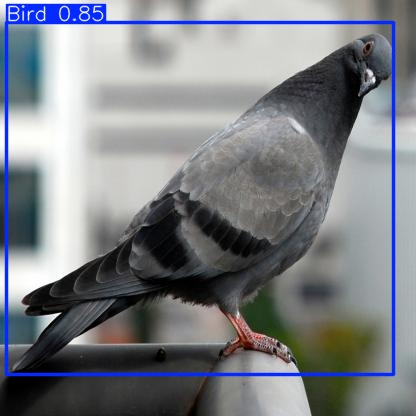

In [6]:
# Predict on a test image
results = model.predict(source='/content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/test/images', save=True, conf=0.5)

from IPython.display import Image, display


if results and hasattr(results[0], 'save_dir'):
    output_dir = results[0].save_dir
    # Assuming we want to display the first processed image from the source

    # A safer way to get an image from the output directory:
    import glob
    output_images = glob.glob(os.path.join(output_dir, '*.jpg')) # Or whatever image format
    if output_images:
        display(Image(filename=output_images[0]))
    else:
        print(f"No output images found in {output_dir}")
else:
    print("Prediction results not available or no images saved.")

### Validation and Inference

In [7]:
from ultralytics import YOLO

# Load the best weights
# Corrected path to aerial_yolo_train2
model_path = '/content/drive/MyDrive/Colab Notebooks/Project_5/aerial_yolo_train2/weights/best.pt'
model = YOLO(model_path)

# Run Validation
# This will give you the mAP score for your report
metrics = model.val(data='/content/drive/MyDrive/Colab Notebooks/Project_5/data.yaml')
print(f"Final mAP Score: {metrics.box.map50}")

# Run Inference
# This will save images with bounding boxes in /content/runs/detect/predict/
test_images = '/content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/test/images'
model.predict(source=test_images, save=True, conf=0.5)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 9.4±4.4 MB/s, size: 15.9 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Project_5/object_detection_Dataset/valid/labels.cache... 448 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 448/448 156.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.3it/s 8.4s
                   all        448        663      0.883      0.743      0.825      0.517
                  Bird        217        414      0.865      0.611      0.736      0.421
                 Drone        225        249      0.901      0.876      0.914      0.614
Speed: 3.0ms preprocess, 4.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val2
Final mAP Score: 0.8246640289381661

image 1/224 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Bird', 1: 'Drone'}
 obb: None
 orig_img: array([[[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        [[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        [[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        ...,
 
        [[74, 48, 34],
         [74, 48, 34],
         [74, 48, 34],
         ...,
         [81, 55, 38],
         [81, 55, 38],
         [81, 55, 38]],
 
        [[74, 48, 34],
         [74, 48, 34],
         [74, 48, 34],
         ...,
         [81, 55, 38],
         [81, 55, 38],
         [81, 55, 38]],
 
        [[74, 48,